# Training LF NN

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, kCrossValSingle
from time import perf_counter
import pandas

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
########################     PREPARATION      ##########################

Nlf_models = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/N_bases.txt").astype(int)   #list of number of bases
U_train_LF_full = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Ulf_train_young.txt")


n_bases = U_train_LF_full.shape[1]                                # <--------
m = list(Nlf_models).index(n_bases)     # maximal nb. of basis

In [3]:
#########################     TRAIN SET      ##########################
mu_train_LF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_LF_young.txt")[:,0]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN
# ADD NOISE
noise_stddev = np.mean(mu_train_LF)*0.1
noise = np.random.normal(0, noise_stddev, len(mu_train_LF))
mu_train_LF=mu_train_LF+noise

permutation = np.random.permutation(len(mu_train_LF))
mu_train_LF=mu_train_LF[permutation][0:10]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN


noise_stddev = 0.005
noise = np.random.normal(0, noise_stddev, np.shape(U_train_LF_full))
U_train_LF_full=U_train_LF_full+noise
m=1

U_lf_train_full = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Ulf_train_young.txt")
U_lf_train = U_lf_train_full[:,m]
U_lf_train=U_lf_train[permutation][0:10]

NepoLF = 3000                          # number of epochs for first NN: NN_LF

In [4]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/mu_test_young.txt")[:,0]
N_test = np.size(mu_test)

U_lf_test_full = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Ulf_test_young.txt")
U_lf_test = U_lf_test_full[:,m]


In [5]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test)
mu_min = np.min(mu_test)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_LF_norm = (mu_train_LF - mu_min) / (mu_max - mu_min)

#Transformation 
U_lf_train = np.exp(U_lf_train*100)*1e-6
U_lf_test = np.exp(U_lf_test*100)*1e-6
#Output
lfmean = np.mean(U_lf_test)

U_lf_train = U_lf_train - lfmean
U_lf_test = U_lf_test - lfmean

start = perf_counter()
#########
mu_final = np.vstack((mu_train_LF_norm))#.transpose() # <- TRAINING INPUT for the second NN: NN_HF
########

In [6]:
##########################       NN_LF     ##########################
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 2
name = 'LF'
K.clear_session()
bayes_trials = Trials()
opt_list = ['Adam','Adamax']
kernel_list = ['uniform','glorot_uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
     'kernel_init': hp.choice('kernel_init',kernel_list),
     'opt' : hp.choice('opt',opt_list)}

def objective(params):
    K.clear_session()
    CVres = kCrossValSingle(Nlf,NepoLF,mu_final, U_lf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)

#bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'} # where do they come from 

#modelLF = getModel(bestLF_params,'LF')
#histLF = modelLF.fit(mu_train_LF_norm, U_lf_train ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
#print('LF NN done')

#ULF = modelLF.predict(mu_test_norm)
#print('\nLF Model:')

#test_mse = np.mean(np.square(U_lf_test - ULF[:,0]))
#print(f"Test MSE: {test_mse}")

#r_2 = 1 - np.sum(np.square(U_lf_test - ULF[:,0])) / np.sum(np.square(U_lf_test - np.mean(U_lf_test)))
#print(f"R^2: {r_2}")

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 113ms/step

1/1 [==============================] - 0s 19ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 16ms/step 

1/1 [==============================] - 0s 22ms/step 

1/1 [==============================] - 0s 30ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 29ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 83ms/step                              

1/1 [==============================] - 0s 41ms/step                              

1/1 [==============================] - 0s 34ms/step                              

1/1 [==============================] - 0s 33ms/step                              

1/1 [==============================] - 0s 31ms/step                              

1/1 [==============================] - 0s 27m

100%|██████████| 15/15 [2:05:52<00:00, 503.49s/trial, best loss: 4.315567633425761e-10]
{'kernel_init': 'glorot_uniform', 'l2weight': 46.15802738473701, 'lr': 0.000136387023594357, 'nodes': 30.0, 'opt': 'Adamax'}

In [7]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()
finalModel = getModel(best_params,name) #final model chosen according to the best paramters
hist = finalModel.fit(mu_train_LF_norm, U_lf_train, validation_data=(mu_test_norm, U_lf_test),epochs=NepoLF,batch_size=Nlf,verbose=0, validation_freq = 20)

ULF = finalModel.predict(mu_test_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nLF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nLF Model:')

test_mse = np.mean(np.square(U_lf_test - ULF[:,0]))
print(f"Test MSE: {test_mse}")

r2_LF = 1 - np.sum(np.square(U_lf_test - ULF[:,0])) / np.sum(np.square(U_lf_test - np.mean(U_lf_test)))
print(f"R^2: {r2_LF}")

print('Number of basis functions: ', int(Nlf_models[m]))
#print('Number of LF data: ', n_LF)

4/4 [==============================] - 0s 0s/step
Elapsed time:  278.06939430000057

LF Model:
Elapsed time:  18.785338800000318

LF Model:
Test MSE: 0.09212244198942832
R^2: -0.12104907128546372
Number of basis functions:  2


4/4 [==============================] - 0s 3ms/step
Elapsed time:  65344.67840039986

HF Model:
Test MSE: 6.354208431374094e-08
R^2: 0.9980795589286997
Number of basis functions:  4

4/4 [==============================] - 0s 0s/step


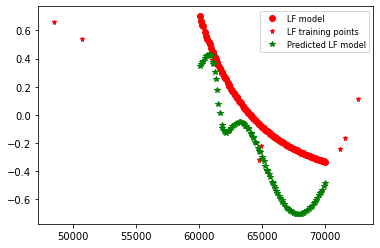

In [8]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(mu_test, U_lf_test,'ro', linewidth = 1.5, label = 'LF model')
plt.plot(mu_train_LF, U_lf_train,'r*', markersize = 5, label = 'LF training points')
plt.plot(mu_test, finalModel.predict(mu_test_norm),'g*' ,linewidth = 3,  label = 'Predicted LF model')
plt.legend(prop={'size': 8.3})
plt.show()
